# Task 1: EDA and Preprocessing — CFPB Complaint Data

This notebook loads the raw CFPB complaint dataset, filters it to four financial products, explores the data through charts, cleans the narratives, and saves the final dataset ready for the RAG pipeline.

**Products covered:** Credit Card · Savings Account · Money Transfer · Personal Loan

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Quick Look at the Raw Data

Before loading anything large, we read just five rows to confirm column names and understand the dataset structure.

In [20]:
# adjust path to wherever your complaints.csv file lives
RAW_CSV = "../data/raw/complaints.csv"

df_peek = pd.read_csv(RAW_CSV, nrows=5)
print("Columns:", df_peek.columns.tolist())
df_peek.head()

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


The dataset has 18 columns. We only need 9 of them — the rest are CFPB internal metadata that adds no value to our complaint analysis.

## 2. Exploring Product Categories

We scan the Product column across all rows to find the exact names that match our four target categories before doing any heavy filtering.

In [21]:
products = pd.read_csv(RAW_CSV, usecols=["Product"])
print(products["Product"].value_counts().to_string())

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

The dataset covers 21 product types. Our four targets appear under multiple name variants — for example Personal Loan is split across "Consumer Loan", "Payday loan, title loan, or personal loan", and two other names. We use keyword matching to catch all variants cleanly.

## 3. Counting Total Raw Records

We count lines in the raw file without loading it into memory to document the true dataset size.

In [22]:
with open(RAW_CSV, "r", encoding="utf-8", errors="ignore") as f:
    raw_row_count = sum(1 for line in f) - 1  # subtract header line

print(f"Total rows in raw dataset: {raw_row_count:,}")

Total rows in raw dataset: 17,536,785


## 4. Loading and Filtering — Chunked Reading

Reading the full dataset at once would crash a standard laptop. We read 100,000 rows at a time, keep only our four product categories, drop rows with no narrative, and discard entries under 10 words. Only 9 of the 18 columns are loaded — this alone cuts memory usage roughly in half.

In [23]:
TARGET_KEYWORDS = [
    "credit card",
    "checking or savings",
    "bank account or service",
    "money transfer",
    "personal loan",
    "payday loan",
    "consumer loan"
]

COLS_TO_KEEP = [
    "Date received",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company",
    "State",
    "Complaint ID"
]

filtered_chunks = []
total_raw = 0
chunk_num = 0

for chunk in pd.read_csv(RAW_CSV, chunksize=100_000, usecols=COLS_TO_KEEP, low_memory=False):
    total_raw += len(chunk)
    chunk_num += 1

    mask = chunk["Product"].str.lower().str.contains(
        "|".join(TARGET_KEYWORDS), na=False
    )
    chunk = chunk[mask]
    chunk = chunk.dropna(subset=["Consumer complaint narrative"])
    chunk = chunk[chunk["Consumer complaint narrative"].str.split().str.len() > 10]

    if len(chunk) > 0:
        filtered_chunks.append(chunk)

    if chunk_num % 10 == 0:
        kept = sum(len(c) for c in filtered_chunks)
        print(f"Processed {total_raw:,} rows... kept {kept:,} so far")

df = pd.concat(filtered_chunks, ignore_index=True)

print(f"\nTotal raw rows read : {total_raw:,}")
print(f"After filtering     : {len(df):,}")
print(f"\nProduct breakdown:")
print(df["Product"].value_counts())

Processed 1,000,000 rows... kept 19,884 so far
Processed 2,000,000 rows... kept 60,168 so far
Processed 3,000,000 rows... kept 97,892 so far
Processed 4,000,000 rows... kept 143,500 so far
Processed 5,000,000 rows... kept 203,023 so far
Processed 6,000,000 rows... kept 271,007 so far
Processed 7,000,000 rows... kept 341,534 so far
Processed 8,000,000 rows... kept 398,997 so far
Processed 9,000,000 rows... kept 445,091 so far

Total raw rows read : 9,609,797
After filtering     : 477,589

Product breakdown:
Product
Checking or savings account                                139210
Credit card or prepaid card                                108168
Money transfer, virtual currency, or money service          96608
Credit card                                                 80232
Payday loan, title loan, or personal loan                   17095
Bank account or service                                     14834
Consumer Loan                                                9399
Payday loan, title

Out of 9.6 million raw records, **477,589** belong to our four target products and have a usable complaint narrative — roughly 5% of the full dataset. The rest are mortgages, debt collection, student loans, and other categories outside the project scope.

## 5. Standardizing Product Names

The CFPB uses long, inconsistent product names. We map all variants to four clean labels for easier analysis and consistent labeling throughout the pipeline.

In [24]:
def map_product(product):
    p = product.lower()
    if "credit card" in p:
        return "Credit Card"
    elif "checking" in p or "savings" in p or "bank account" in p:
        return "Savings Account"
    elif "money transfer" in p:
        return "Money Transfer"
    elif "loan" in p or "consumer loan" in p:
        return "Personal Loan"
    else:
        return "Other"

df["product_category"] = df["Product"].apply(map_product)

print(df.shape)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nClean category breakdown:")
print(df["product_category"].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())

(477589, 10)

Memory usage: 662.0 MB

Clean category breakdown:
product_category
Credit Card        188400
Savings Account    154044
Money Transfer      98101
Personal Loan       37044
Name: count, dtype: int64

Missing values:
Date received                        0
Product                              0
Sub-product                      20503
Issue                                0
Sub-issue                       168671
Consumer complaint narrative         0
Company                              0
State                             5497
Complaint ID                         0
product_category                     0
dtype: int64


Credit Card dominates with 188,400 complaints. Personal Loan has the fewest at 37,044 — about five times less than Credit Card. Sub-issue is missing for 35% of rows, which is expected since it is an optional field in the CFPB submission portal.

## 6. Complaint Volume by Product

How are complaints distributed across our four categories?

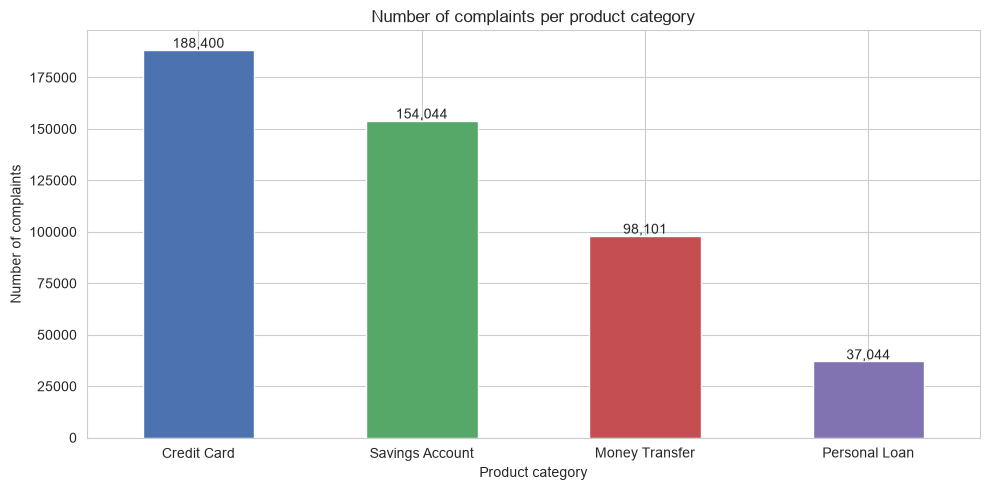

Chart saved.


In [25]:
os.makedirs("../notebooks/eda_plots", exist_ok=True)

plt.figure(figsize=(10, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

counts = df["product_category"].value_counts()
counts.plot(kind="bar", color=colors, edgecolor="white")

plt.title("Number of complaints per product category")
plt.xlabel("Product category")
plt.ylabel("Number of complaints")
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    plt.text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../notebooks/eda_plots/product_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

Credit Cards generate the most complaints by far — nearly 40% of the filtered dataset. This makes sense since credit cards have the most consumer touchpoints: billing disputes, fraud, interest charges, and account management.

## 7. How Long Are the Narratives?

Understanding narrative length matters for Task 2 chunking. Chunks that are too small lose context. Chunks that are too large are hard for the embedding model to represent as a single vector.

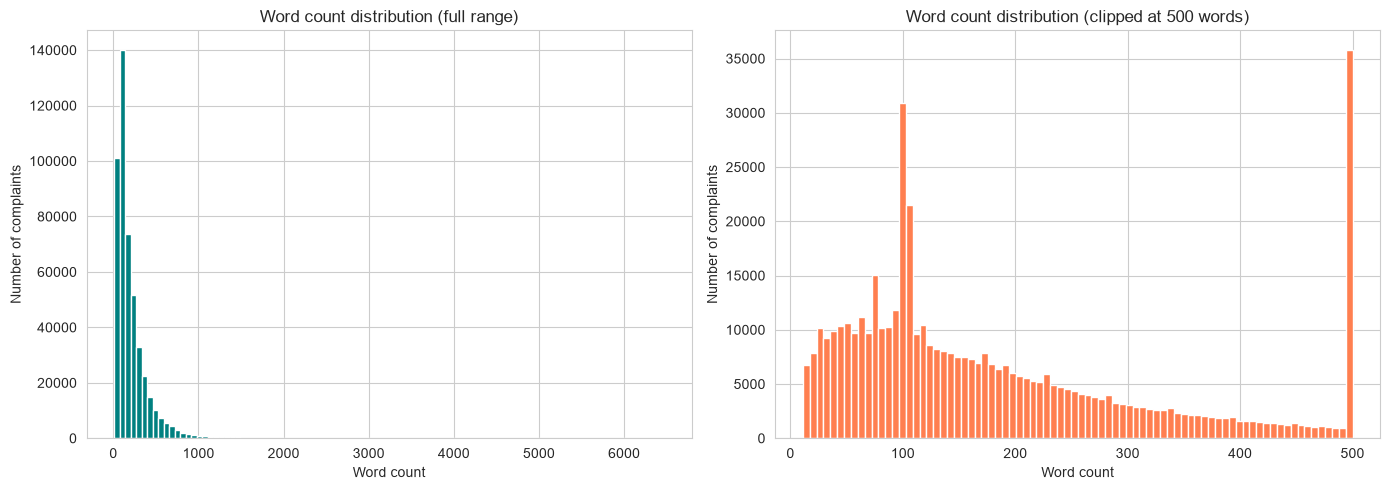

count    477589.0
mean        206.8
std         225.7
min          11.0
25%          84.0
50%         139.0
75%         257.0
max        6469.0
Name: word_count, dtype: float64

Very short — under 20 words  : 8,959
Medium     — 20 to 200 words : 301,992
Very long  — over 400 words  : 55,365


In [26]:
df["word_count"] = df["Consumer complaint narrative"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["word_count"], bins=100, color="teal", edgecolor="white")
axes[0].set_title("Word count distribution (full range)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of complaints")

axes[1].hist(df["word_count"].clip(upper=500), bins=80, color="coral", edgecolor="white")
axes[1].set_title("Word count distribution (clipped at 500 words)")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Number of complaints")

plt.tight_layout()
plt.savefig("../notebooks/eda_plots/word_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(df["word_count"].describe().round(1))
print(f"\nVery short — under 20 words  : {(df['word_count'] < 20).sum():,}")
print(f"Medium     — 20 to 200 words : {((df['word_count'] >= 20) & (df['word_count'] <= 200)).sum():,}")
print(f"Very long  — over 400 words  : {(df['word_count'] > 400).sum():,}")

Most complaints fall between 50 and 200 words. The distribution is right-skewed — a small number of people write very long complaints over 1,000 words. The chunk size used in the pre-built vector store aligns well with this median length.

## 8. Complaints Over Time

How has complaint volume changed across the years covered by this dataset?

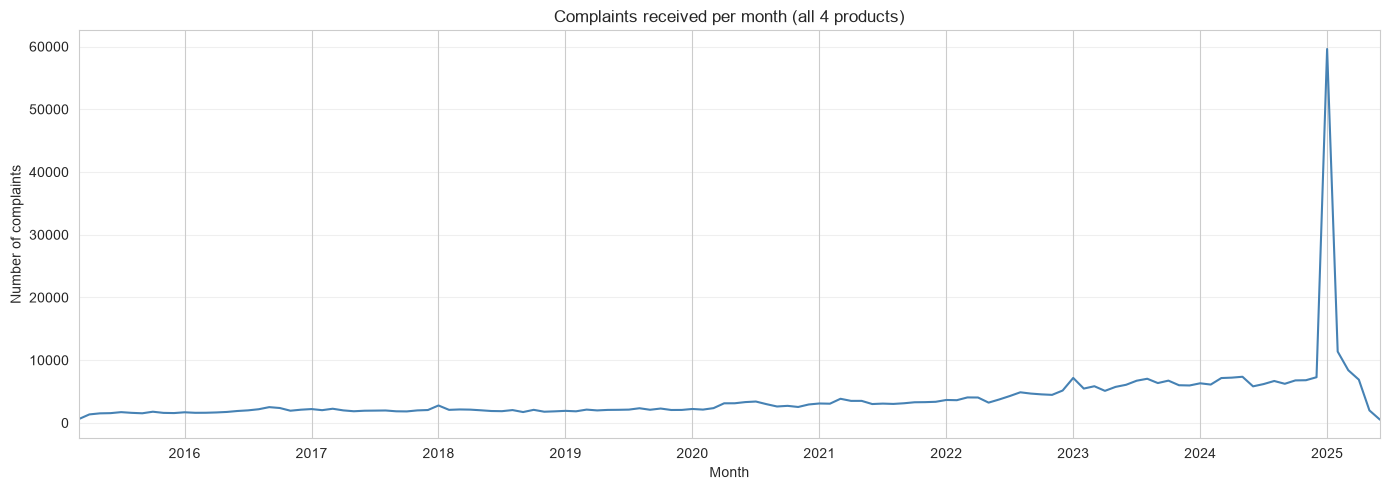

Chart saved.


In [27]:
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
df["year_month"] = df["Date received"].dt.to_period("M")

monthly = df.groupby("year_month").size()

plt.figure(figsize=(14, 5))
monthly.plot(color="steelblue", linewidth=1.5)

plt.title("Complaints received per month (all 4 products)")
plt.xlabel("Month")
plt.ylabel("Number of complaints")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../notebooks/eda_plots/complaints_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

Complaint volume grew steadily from 2015 to 2024. The dramatic spike in early 2025 is the most striking finding — this likely reflects a specific regulatory event or product issue rather than organic growth. This kind of signal is exactly what the RAG chatbot is designed to surface quickly.

## 9. Inspecting Raw Narratives

Before writing cleaning rules, we look at actual complaint text to understand what noise exists in the data.

In [28]:
for i, row in df[["product_category", "Consumer complaint narrative"]].head(3).iterrows():
    print(f"--- Product: {row['product_category']} ---")
    print(row["Consumer complaint narrative"][:300])
    print()

--- Product: Credit Card ---
A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However

--- Product: Savings Account ---
I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch. 

I went into the branch and was told they couldn't help and had to phone the customer service for help. I did this and was told I was helped gave all the info for the time terminal i

--- Product: Credit Card ---
Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I have been calling n waitting for the check release the secured amount {$2500.00} for rhat credit card. They told me to wait then today they told me someone cashed my check but their system doesnt have info



From these samples we can identify four patterns worth cleaning: XXXX redactions inserted by the CFPB privacy process, money amounts written as `{$2500.00}`, boilerplate openers like "Dear CFPB", and inconsistent casing throughout.

## 10. Checking Boilerplate Frequency

Before removing patterns, we confirm how common they are. No point writing a cleaning rule for something that appears in only a handful of rows.

In [29]:
narrative = df["Consumer complaint narrative"].str.lower()

print("Contains 'i am writing'   :", narrative.str.contains("i am writing", na=False).sum())
print("Contains 'to whom it may' :", narrative.str.contains("to whom it may", na=False).sum())
print("Contains 'xx' redactions  :", narrative.str.contains("xx", na=False).sum())
print("Contains '{$' amounts     :", narrative.str.contains(r"\{\$", na=False).sum())
print("Contains 'dear cfpb'      :", narrative.str.contains("dear cfpb", na=False).sum())

Contains 'i am writing'   : 26744
Contains 'to whom it may' : 3304
Contains 'xx' redactions  : 366976
Contains '{$' amounts     : 199198
Contains 'dear cfpb'      : 1187


## 11. Text Cleaning

We apply four targeted cleaning steps based on what we found in the inspection above:

1. Lowercase everything for consistency
2. Remove boilerplate openers like "Dear CFPB"
3. Standardize money amounts from `{$2500.00}` format to the word `AMOUNT`
4. Remove XXXX redactions and strip special characters

In [30]:
def clean_narrative(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"dear cfpb,?", "", text)
    text = re.sub(r"to whom it may concern,?", "", text)
    text = re.sub(r"i am writing to (file|submit|make) a complaint.*?\.", "", text)
    text = re.sub(r"\{\$[\d,]+\.?\d*\}", "AMOUNT", text)
    text = re.sub(r"x{2,}", "", text)
    text = re.sub(r"[^a-z0-9\s.,!?;\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# show before and after for 3 examples
for i, row in df["Consumer complaint narrative"].head(3).items():
    print("BEFORE:")
    print(row[:200])
    print("\nAFTER:")
    print(clean_narrative(row)[:200])
    print("\n" + "=" * 60 + "\n")

BEFORE:
A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unaut

AFTER:
a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confir


BEFORE:
I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch. 

I went into the branch and was told they couldn't help and had to phone the custo

AFTER:
i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their branch. i went into the branch and was told they couldn t help and had to phone the customer service


BEFORE:
Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I have been calling n waitting for the check release the se

The cleaning function preserves the full meaning and structure of each complaint while removing noise. Lowercase normalization ensures consistent tokenization in the embedding step.

## 12. Applying Cleaning to All Narratives

We apply the cleaning function across all 477K narratives and drop any rows where cleaning left us with fewer than 10 words.

In [31]:
print("Cleaning all narratives... this may take 1-2 minutes.")

df["clean_narrative"] = df["Consumer complaint narrative"].apply(clean_narrative)

before = len(df)
df = df[df["clean_narrative"].str.split().str.len() > 10]
after = len(df)

print(f"Rows before cleaning filter : {before:,}")
print(f"Rows after cleaning filter  : {after:,}")
print(f"Rows removed                : {before - after:,}")
print("\nSample cleaned narrative:")
print(df["clean_narrative"].iloc[0][:300])

Cleaning all narratives... this may take 1-2 minutes.
Rows before cleaning filter : 477,589
Rows after cleaning filter  : 477,114
Rows removed                : 475

Sample cleaned narrative:
a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confirmed this was fraudulent and immediately closed the card. however, they have failed to remove this fr


## 13. Saving the Cleaned Dataset

The cleaned dataset is saved to `data/processed/` — this file is the starting point for Task 2 text chunking and embedding.

In [32]:
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/filtered_complaints.csv", index=False)

print(f"Saved to data/processed/filtered_complaints.csv")
print(f"Final shape : {df.shape}")
print(f"\nColumns saved:")
print(df.columns.tolist())

Saved to data/processed/filtered_complaints.csv
Final shape : (477114, 13)

Columns saved:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company', 'State', 'Complaint ID', 'product_category', 'word_count', 'year_month', 'clean_narrative']


Task 1 complete. The cleaned dataset (`filtered_complaints.csv`) contains all four product categories with standardized labels and clean narrative text. It is ready for chunking and embedding in Task 2.